In [1]:
import kagglehub
path = kagglehub.dataset_download("benroshan/factors-affecting-campus-placement")

100%|██████████| 4.51k/4.51k [00:00<00:00, 4.49MB/s]

Extracting files...


In [10]:
!pip install --ignore-installed blinker
!pip install streamlit

In [11]:
!pip install streamlit pyngrok

In [12]:
from pyngrok import ngrok
ngrok.set_auth_token("3H2nxZtP4iC5L9tX9K97OPLut9W_4JsZrRVF5aRFQpQCCePy1")

In [21]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:8501"


In [22]:
# Run the Streamlit app
# This will provide a public URL to access the app
!streamlit run app.py &




2026-08-21 00:28:42.654 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.187.152.206:8501

  Stopping...


In [18]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import tensorflow as tf
import time

# Load the saved model and preprocessor
@st.cache_resource
def load_resources():
    model = tf.keras.models.load_model('placement_model.h5')
    preprocessor = joblib.load('preprocessor.pkl')
    return model, preprocessor

model, preprocessor = load_resources()

# --- Streamlit App Design ---

# Optional: Add a logo (uncomment and replace 'logo.png' with your image file path)
# try:
#     st.image('logo.png', width=100)
# except FileNotFoundError:
#     st.warning('Logo file not found. Please upload `logo.png` to the same directory as this app.')

st.title('🎓 Campus Placement Predictor')
st.markdown('### Discover your placement chances!')
st.write('Enter the student details to predict placement status.')

# Create input widgets for each feature in a sidebar for better layout
with st.sidebar:
    st.header('Student Details')

    gender = st.radio('Gender', ['M', 'F'])
    ssc_p = st.slider('SSC Percentage', min_value=0.0, max_value=100.0, value=70.0, step=0.1)
    ssc_b = st.selectbox('SSC Board', ['Central', 'Others'])
    hsc_p = st.slider('HSC Percentage', min_value=0.0, max_value=100.0, value=70.0, step=0.1)
    hsc_b = st.selectbox('HSC Board', ['Central', 'Others'])
    hsc_s = st.selectbox('HSC Specialization', ['Commerce', 'Science', 'Arts'])
    degree_p = st.slider('Degree Percentage', min_value=0.0, max_value=100.0, value=70.0, step=0.1)
    degree_t = st.selectbox('Degree Type', ['Sci&Tech', 'Comm&Mgmt', 'Others'])
    workex = st.radio('Work Experience', ['No', 'Yes'])
    etest_p = st.slider('Employability Test Percentage', min_value=0.0, max_value=100.0, value=70.0, step=0.1)
    specialisation = st.selectbox('MBA Specialisation', ['Mkt&HR', 'Mkt&Fin'])
    mba_p = st.slider('MBA Percentage', min_value=0.0, max_value=100.0, value=60.0, step=0.1)
    salary = 0.0 # Placeholder for prediction input, as salary is an output of placement

# Create a DataFrame from the inputs (ensure column order matches training data X)
input_data = pd.DataFrame([{
    'gender': gender,
    'ssc_p': ssc_p,
    'ssc_b': ssc_b,
    'hsc_p': hsc_p,
    'hsc_b': hsc_b,
    'hsc_s': hsc_s,
    'degree_p': degree_p,
    'degree_t': degree_t,
    'workex': workex,
    'etest_p': etest_p,
    'specialisation': specialisation,
    'mba_p': mba_p,
    'salary': salary # Kept as 0 for prediction
}])

# Prediction Button
if st.button('🚀 Predict Placement Status'):
    with st.spinner('Calculating prediction...'):
        time.sleep(2) # Simulate some processing time

        # Preprocess the input data
        processed_input = preprocessor.transform(input_data)

        # Make prediction
        prediction = model.predict(processed_input)
        predicted_class = (prediction > 0.5).astype(int)[0][0]

    st.markdown('---') # Separator
    if predicted_class == 1:
        st.balloons()
        st.success('🎉 Congratulations! The student is predicted to be PLACED!')
        st.markdown(f"Probability of Placement: **{prediction[0][0]*100:.2f}%**")
    else:
        st.warning('😔 The student is predicted to be NOT PLACED.')
        st.markdown(f"Probability of Placement: **{prediction[0][0]*100:.2f}%**")

st.markdown('---')
st.info('Adjust the parameters in the sidebar and click "Predict Placement Status" to get new predictions.')

Overwriting app.py


In [19]:
# Re-run the Streamlit app to apply changes
!nohup streamlit run app.py --server.port 80 --server.enableCORS false &>/dev/null &

In [20]:
from pyngrok import ngrok

# Terminate any existing ngrok tunnels
ngrok.kill()

# Assuming NGROK_AUTH_TOKEN is already set, or the user will set it again if needed.
# Set up a tunnel to port 80 (where Streamlit is running)
public_url = ngrok.connect(addr='80', proto='http')

print(f"Updated Streamlit App URL: {public_url}")

Updated Streamlit App URL: NgrokTunnel: "https://vanity-amperage-commodore.ngrok-free.dev" -> "http://localhost:80"


In [2]:
import os
import pandas as pd

# List the contents of the downloaded directory to find the CSV file
dataset_files = os.listdir(path)
print(f"Files in the dataset directory: {dataset_files}")

# Assuming the CSV file is the only CSV or the most relevant one
csv_file_name = [f for f in dataset_files if f.endswith('.csv')][0]
full_csv_path = os.path.join(path, csv_file_name)

# Load the dataset into a pandas DataFrame
df = pd.read_csv(full_csv_path)

# Display the first 5 rows of the DataFrame
display(df.head())

# Display information about the DataFrame, including data types and non-null values
df.info()

Files in the dataset directory: ['Placement_Data_Full_Class.csv']


,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sl_no           215 non-null    int64  
 1   gender          215 non-null    object 
 2   ssc_p           215 non-null    float64
 3   ssc_b           215 non-null    object 
 4   hsc_p           215 non-null    float64
 5   hsc_b           215 non-null    object 
 6   hsc_s           215 non-null    object 
 7   degree_p        215 non-null    float64
 8   degree_t        215 non-null    object 
 9   workex          215 non-null    object 
 10  etest_p         215 non-null    float64
 11  specialisation  215 non-null    object 
 12  mba_p           215 non-null    float64
 13  status          215 non-null    object 
 14  salary          148 non-null    float64
dtypes: float64(6), int64(1), object(8)
memory usage: 25.3+ KB


In [3]:
# Fill NaN values in 'salary' with 0, assuming 'Not Placed' implies 0 salary.
df['salary'] = df['salary'].fillna(0)

# Display the count of missing values for each column after filling 'salary'
print("Missing values after filling 'salary':")
print(df.isnull().sum())

# Drop the 'sl_no' column as it's an identifier and not useful for prediction
df = df.drop('sl_no', axis=1)

# Display the first few rows of the preprocessed DataFrame and its info to confirm changes
display(df.head())
df.info()

Missing values after filling 'salary':
sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64


,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,0.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   gender          215 non-null    object 
 1   ssc_p           215 non-null    float64
 2   ssc_b           215 non-null    object 
 3   hsc_p           215 non-null    float64
 4   hsc_b           215 non-null    object 
 5   hsc_s           215 non-null    object 
 6   degree_p        215 non-null    float64
 7   degree_t        215 non-null    object 
 8   workex          215 non-null    object 
 9   etest_p         215 non-null    float64
 10  specialisation  215 non-null    object 
 11  mba_p           215 non-null    float64
 12  status          215 non-null    object 
 13  salary          215 non-null    float64
dtypes: float64(6), object(8)
memory usage: 23.6+ KB


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Define features (X) and target (y)
X = df.drop('status', axis=1)
y = df['status']

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns

print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

# Create a preprocessing pipeline for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Encode the target variable 'status' (Placed: 1, Not Placed: 0)
y = y.apply(lambda x: 1 if x == 'Placed' else 0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Apply the preprocessing pipeline to the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of processed training data: {X_train_processed.shape}")
print(f"Shape of processed testing data: {X_test_processed.shape}")

Categorical features: ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']
Numerical features: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
X_train shape: (172, 13)
X_test shape: (43, 13)
y_train shape: (172,)
y_test shape: (43,)
Shape of processed training data: (172, 22)
Shape of processed testing data: (43, 22)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.2701 - loss: 0.7751 - val_accuracy: 0.5143 - val_loss: 0.6752
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5255 - loss: 0.6892 - val_accuracy: 0.6286 - val_loss: 0.6134
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6277 - loss: 0.6239 - val_accuracy: 0.7714 - val_loss: 0.5618
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7518 - loss: 0.5665 - val_accuracy: 0.8000 - val_loss: 0.5167
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8175 - loss: 0.5141 - val_accuracy: 0.8571 - val_loss: 0.4740
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8540 - loss: 0.4619 - val_accuracy: 0.8571 - val_loss: 0.4357
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8905 - loss: 0.4130 - val_accuracy: 0.8286 - val_loss: 0.3989
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8978 - loss: 0.3657 - val_accuracy: 0.8286 - val_loss: 0.3644


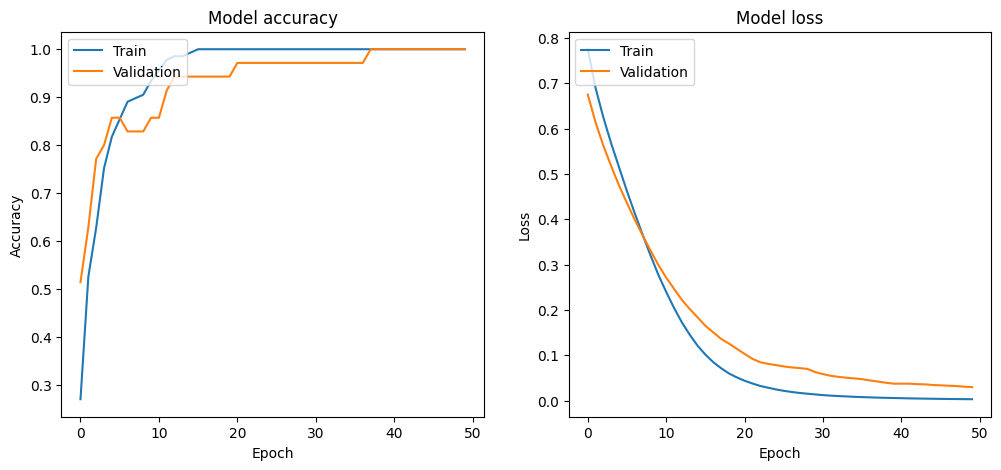

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the deep learning model architecture
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_processed.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Display model summary
model.summary()

# Train the model
history = model.fit(X_train_processed, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_processed, y_test, verbose=0)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

In [6]:
import joblib
import os

# Define paths to save the preprocessor and model
model_save_path = 'placement_model.h5'
preprocessor_save_path = 'preprocessor.pkl'

# Save the Keras model
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# Save the preprocessor
joblib.dump(preprocessor, preprocessor_save_path)
print(f"Preprocessor saved to {preprocessor_save_path}")

Model saved to placement_model.h5
Preprocessor saved to preprocessor.pkl


In [7]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import tensorflow as tf

# Load the saved model and preprocessor
@st.cache_resource
def load_resources():
    model = tf.keras.models.load_model('placement_model.h5')
    preprocessor = joblib.load('preprocessor.pkl')
    return model, preprocessor

model, preprocessor = load_resources()

# Define the features (must match the order and names used during training)
categorical_features = ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation']
numerical_features = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']

st.title('Campus Placement Prediction')
st.write('Enter the student details to predict placement status.')

# Create input widgets for each feature
with st.sidebar:
    st.header('Student Details')
    gender = st.selectbox('Gender', ['M', 'F'])
    ssc_p = st.number_input('SSC Percentage', min_value=0.0, max_value=100.0, value=70.0)
    ssc_b = st.selectbox('SSC Board', ['Central', 'Others'])
    hsc_p = st.number_input('HSC Percentage', min_value=0.0, max_value=100.0, value=70.0)
    hsc_b = st.selectbox('HSC Board', ['Central', 'Others'])
    hsc_s = st.selectbox('HSC Specialization', ['Commerce', 'Science', 'Arts'])
    degree_p = st.number_input('Degree Percentage', min_value=0.0, max_value=100.0, value=70.0)
    degree_t = st.selectbox('Degree Type', ['Sci&Tech', 'Comm&Mgmt', 'Others'])
    workex = st.selectbox('Work Experience', ['No', 'Yes'])
    etest_p = st.number_input('Employability Test Percentage', min_value=0.0, max_value=100.0, value=70.0)
    specialisation = st.selectbox('MBA Specialisation', ['Mkt&HR', 'Mkt&Fin'])
    mba_p = st.number_input('MBA Percentage', min_value=0.0, max_value=100.0, value=60.0)
    # Salary is the target variable, but if we are predicting placement, it might not be an input.
    # However, in some contexts, it might represent expected salary for 'Placed' candidates,
    # or be zero for 'Not Placed'. For prediction, we might not include it as input.
    # For this app, let's assume 'salary' is not an input for the prediction of 'status'.
    # If the model was trained to predict salary given status, it would be different.
    # Since the goal is to predict 'status', we will set salary to a default value (e.g., 0).
    salary = 0.0 # Placeholder, as salary is a potential output, not an input for placement prediction

# Create a DataFrame from the inputs (ensure column order matches training data X)
input_data = pd.DataFrame([{
    'gender': gender,
    'ssc_p': ssc_p,
    'ssc_b': ssc_b,
    'hsc_p': hsc_p,
    'hsc_b': hsc_b,
    'hsc_s': hsc_s,
    'degree_p': degree_p,
    'degree_t': degree_t,
    'workex': workex,
    'etest_p': etest_p,
    'specialisation': specialisation,
    'mba_p': mba_p,
    'salary': salary # This column was in X, so it must be present here.
                        # If predicting placement, the actual salary value doesn't matter for *this* prediction
                        # as it would be 0 for 'Not Placed' and non-zero for 'Placed'.
                        # Since our model was trained with salary as a feature in X, it needs a value.
                        # Let's assume 0 for prediction, as we are trying to predict the 'status'.
                        # If the student *is* placed, the salary would be predicted separately or estimated.
}])

if st.button('Predict Placement'):
    # Preprocess the input data
    processed_input = preprocessor.transform(input_data)

    # Make prediction
    prediction = model.predict(processed_input)
    predicted_class = (prediction > 0.5).astype(int)[0][0]

    if predicted_class == 1:
        st.success('The student is predicted to be PLACED!')
    else:
        st.error('The student is predicted to be NOT PLACED.')


Writing app.py


Now, let's install Streamlit and ngrok, and then run the app.py file.

In [8]:
!pip install streamlit pyngrok -qq
!nohup streamlit run app.py --server.port 80 --server.enableCORS false &>/dev/null &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 49.7 MB/s eta 0:00:00


In [9]:
from pyngrok import ngrok

# Terminate any existing ngrok tunnels
ngrok.kill()

# Set up a tunnel to port 80 (where Streamlit is running)
public_url = ngrok.connect(addr='80', proto='http')

print(f"Streamlit App URL: {public_url}")

ERROR:pyngrok.process.ngrok:t=2026-08-21T00:24:18+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-08-21T00:24:18+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
CRITICAL:pyngrok.process.ngrok:t=2026-08-21T00:24:18+0000 lvl=crit msg="command failed" err="authentication failed: This ngrok session is not authenticated. ngrok requi

PyngrokNgrokError: The ngrok process errored on start: authentication failed: This ngrok session is not authenticated. ngrok requires an account and a valid credential to start a session.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nGet your credential: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.